In [1]:
# ===================================================
# Module 7: Contour Detection & Object Counting
# ===================================================

# Contour detection is used to find the outline or shape of objects in a binary image.
# A contour is simply a curve that joins all the continuous points along a boundary.

# Why use contours?
# - To count how many objects are present (e.g., bees, leaves, cells)
# - To draw boxes or outlines around each object
# - To extract shapes for further processing (crop, classify, etc.)

# Contours work best on binary images where:
# - Foreground/object = white (255)
# - Background = black (0)

# Workflow:
# 1. Preprocess image (grayscale → blur → threshold → clean)
# 2. Find contours
# 3. Draw them and count them


Number of objects detected: 175


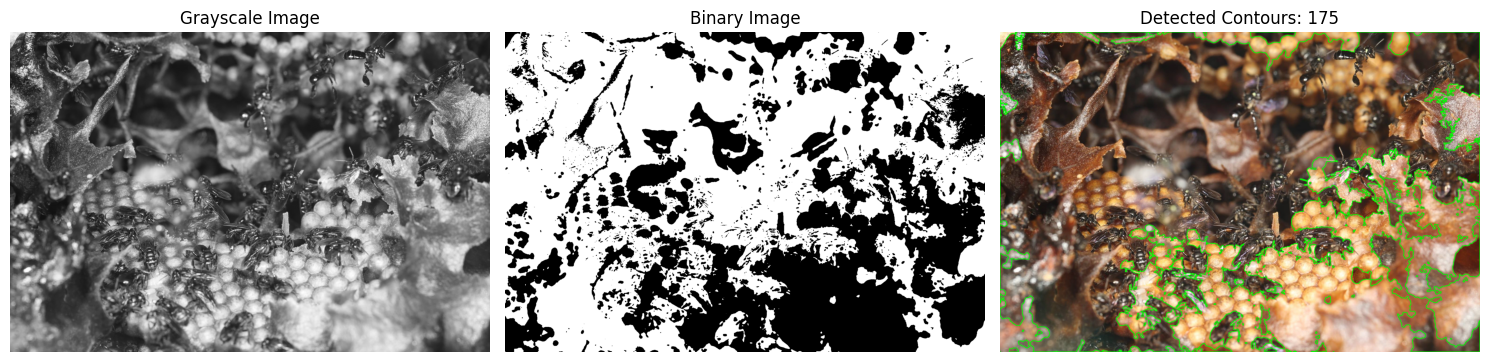

In [2]:
import cv2
import matplotlib.pyplot as plt

# 1. Load and preprocess image
img = cv2.imread('kelulut1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 2. Optional: Clean binary image using morphology
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# 3. Find contours
contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 4. Draw contours on original image
output = img.copy()
cv2.drawContours(output, contours, -1, (0, 255, 0), 2)

# 5. Show number of detected objects
print("Number of objects detected:", len(contours))

# 6. Show results
plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Contours: {len(contours)}")
plt.axis('off')

plt.tight_layout()
plt.show()
